In [2]:
import astra
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage
import sys 
sys.path.append('..')
import amglib.readers as rd
import amglib.imageutils as amg
import amglib.widgets as aw

from scipy.ndimage import shift

import importlib

import astrautils as au

In [3]:
astra.test()

ASTRA Toolbox v2.3.1
Getting GPU info... GPU #0: Quadro RTX 4000, with 8191MB, CUDA compute capability 7.5
Testing basic CPU 2D functionality... Ok
Testing basic CUDA 2D functionality... Ok
Testing basic CUDA 3D functionality... Ok


## Load and prepare data

In [4]:
path = 'D:/Kaestner/P20250668/02_rawdata/01_Config1/01_Calibration/'
proj0 = rd.read_images(path+'cal_{0:05d}.fits',first=1, last=361)
ob0 = rd.read_images(path+'ob_{0:05d}.fits',first=1, last=5).mean(axis=0)
dc0 = rd.read_images(path+'dc_{0:05d}.fits',first=1, last=5).mean(axis=0)

  0%|          | 0/361 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [5]:
proj = proj0-dc0
proj[proj<1]=1
o = ob0-dc0
o[o<1]=1
proj = proj/o 

In [56]:
N = 1
p_small0 = proj[::N,::N,::N]
# p_small = p_small0
p_small = np.transpose(p_small0,(1,0,2))

## Reconstruction

In [9]:
importlib.reload(au)

projections = p_small
# Configuration parameters
SOD = 395
SDD = 1327
distance_source_origin   = 395  # Distance from source to origin (object) (mm)
distance_origin_detector = SDD-SOD  # Distance from origin (object)  to detector (mm)
detector_pixel_size      = 0.139/N  # Detector pixel size (mm)
detector_rows            = projections.shape[0]  # Number of detector rows (pixels)
detector_cols            = projections.shape[2]  # Number of detector columns (pixels)
num_of_projections       = projections.shape[1]  # Number of projections
angles = np.linspace(0, 2 * np.pi, num=num_of_projections, endpoint=False)  # Projection angles

# Divide by magnification
detector_pixel_size_in_origin = detector_pixel_size * distance_source_origin / (distance_source_origin + distance_origin_detector)

proj_geom = astra.create_proj_geom(
    'cone',
    1, 1,
    detector_rows, detector_cols,
    -angles,
    distance_source_origin / detector_pixel_size_in_origin,
    0
)

# Apply the center of rotation correction
proj_geom = astra.geom_postalignment(proj_geom, factor=(0)) #passing the COR offset

# Create ASTRA data object for projections
projections_id = astra.data3d.create('-sino', proj_geom, projections)

# Create ASTRA volume geometry
vol_geom = astra.creators.create_vol_geom(detector_cols, detector_cols, detector_rows)

# Create ASTRA data object for reconstruction
reconstruction_id = astra.data3d.create('-vol', vol_geom, data=0)

# Configure the FDK algorithm
alg_cfg = astra.astra_dict('FDK_CUDA')
alg_cfg['ProjectionDataId'] = projections_id
alg_cfg['ReconstructionDataId'] = reconstruction_id

# Create and run the algorithm
algorithm_id = astra.algorithm.create(alg_cfg)
print("#######running FDK##########")
astra.algorithm.run(algorithm_id)
print("#######finnished FDK##########")

# Retrieve the reconstructed volume
reconstruction = astra.data3d.get(reconstruction_id)

# Post-processing: normalize
reconstruction /= np.max(reconstruction)


#######running FDK##########
#######finnished FDK##########


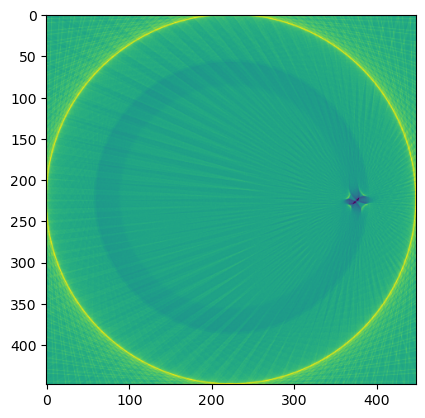

In [10]:
plt.imshow(reconstruction[reconstruction.shape[0]//2])

## Try advanced geometry

In [22]:
def create_cone_vec_geometry(
    angles, SOD, SDD,
    px_size, det_px,
    piercing_px,
    cor=(0, 0, 0) ):
    """
    piercing_px: (py, px) in pixels (row, col) = (height, width) direction
    """
    H, W = det_px
    dy, dx = px_size
    py, px = piercing_px  # detector pixel (row, col) where beam hits

    vectors = []

    M = SDD/SOD
    for theta in angles:
        R = np.array([
            [np.cos(theta), -np.sin(theta), 0],
            [np.sin(theta),  np.cos(theta), 0],
            [0,              0,             1]
        ])

        obj = np.array(cor)
        src = obj + R @ np.array([-SOD, 0, 0])
        det_center_nominal = obj + R @ np.array([(SDD - SOD), 0, 0])

        # Detector axes in world space
        u_vec = R @ np.array([0, dx, 0])  # across columns
        v_vec = R @ np.array([0, 0, dy])  # down rows

        # Offset in pixels from center
        px_offset = (px - W / 2) * u_vec
        py_offset = (py - H / 2) * v_vec

        # Adjusted detector center
        det_c = det_center_nominal + px_offset + py_offset

        vectors.append(np.concatenate([src, det_c, u_vec, v_vec]))

    return np.array(vectors)

In [28]:
importlib.reload(au)

projections = p_small
# Configuration parameters
SOD = 395
SDD = 1327
distance_source_origin   = 395  # Distance from source to origin (object) (mm)
distance_origin_detector = SDD-SOD  # Distance from origin (object)  to detector (mm)
detector_pixel_size      = 0.139/N  # Detector pixel size (mm)
detector_rows            = projections.shape[0]  # Number of detector rows (pixels)
detector_cols            = projections.shape[2]  # Number of detector columns (pixels)
num_of_projections       = projections.shape[1]  # Number of projections
angles = np.linspace(0, 2 * np.pi, num=num_of_projections, endpoint=False)  # Projection angles

# Divide by magnification
detector_pixel_size_in_origin = detector_pixel_size * distance_source_origin / (distance_source_origin + distance_origin_detector)


# proj_geom = astra.create_proj_geom(
#     'cone',
#     1, 1,
#     detector_rows, detector_cols,
#     -angles,
#     distance_source_origin / detector_pixel_size_in_origin,
#     0
# )

geom_vec = create_cone_vec_geometry(
    angles, SOD, SDD-SOD,
    px_size=(detector_pixel_size,detector_pixel_size), 
    det_px=(detector_rows, detector_cols),
    piercing_px=(detector_rows-723/N,0),
    cor=(0, 0, 0) )

proj_geom = astra.create_proj_geom(
    'cone_vec',
    detector_rows, detector_cols, geom_vec)
# Create ASTRA data object for projections
projections_id = astra.data3d.create('-sino', proj_geom, projections)

# Create ASTRA volume geometry
vol_geom = astra.creators.create_vol_geom(detector_cols, detector_cols, detector_rows)

# Create ASTRA data object for reconstruction
reconstruction_id = astra.data3d.create('-vol', vol_geom, data=0)

# Configure the FDK algorithm
alg_cfg = astra.astra_dict('FDK_CUDA')
alg_cfg['ProjectionDataId'] = projections_id
alg_cfg['ReconstructionDataId'] = reconstruction_id

# Create and run the algorithm
algorithm_id = astra.algorithm.create(alg_cfg)
print("#######running FDK##########")
astra.algorithm.run(algorithm_id)
print("#######finnished FDK##########")

# Retrieve the reconstructed volume
reconstruction = astra.data3d.get(reconstruction_id)

# Post-processing: normalize
reconstruction /= np.max(reconstruction)

#######running FDK##########
#######finnished FDK##########


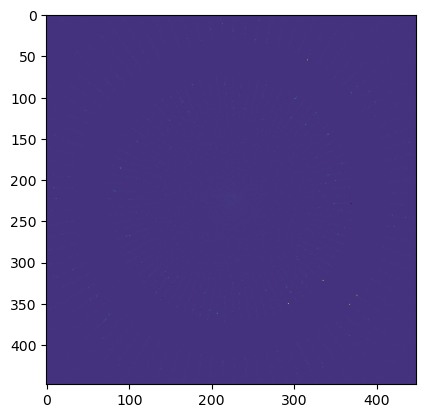

In [29]:
plt.imshow(reconstruction[reconstruction.shape[0]//2])

## Chat version

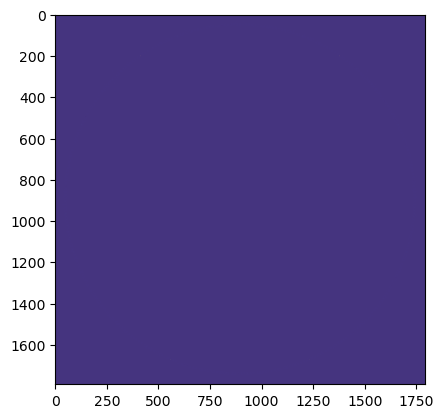

In [57]:
import numpy as np
import astra

# Projections
projections = p_small

# Configuration parameters
SOD = 395  # mm
SDD = 1327  # mm
distance_source_origin = SOD
distance_origin_detector = SDD - SOD  # mm

detector_pixel_size = 0.139 / N  # mm

detector_rows = projections.shape[0]  # rows (v)
detector_cols = projections.shape[2]  # cols (u)
num_of_projections = projections.shape[1]

angles = np.linspace(0, 2 * np.pi, num=num_of_projections, endpoint=False)

# Detector center (piercing point) in pixels (assuming provided or known)
# px, py define where the central beam hits the detector (in pixel units)
px = detector_cols / 2  # adjust as needed
py = 1350/N - detector_rows / 2   # adjust as needed

# Create projection geometry with piercing point shift
M = SOD/SDD
origin_psize = detector_pixel_size/M
proj_geom = astra.create_proj_geom(
    'cone',
    1,1,
    detector_rows, detector_cols,
    angles,
    distance_source_origin/origin_psize,
    0,
    (px - detector_cols / 2) * origin_psize,  # u offset in mm
    (py - detector_rows / 2) * origin_psize   # v offset in mm
)

# Apply center of rotation correction
cor_offset_pixels = 0  # set to your measured/known COR offset
proj_geom = astra.geom_postalignment(proj_geom, cor_offset_pixels)

# Create data objects
projections_id = astra.data3d.create('-sino', proj_geom, projections)
vol_geom = astra.creators.create_vol_geom(detector_cols, detector_cols, detector_rows)
reconstruction_id = astra.data3d.create('-vol', vol_geom)

# FDK reconstruction
cfg = astra.astra_dict('FDK_CUDA')
cfg['ProjectionDataId'] = projections_id
cfg['ReconstructionDataId'] = reconstruction_id
alg_id = astra.algorithm.create(cfg)
astra.algorithm.run(alg_id)

# Retrieve and normalize
reconstruction = astra.data3d.get(reconstruction_id)
reconstruction /= np.max(reconstruction)

# Clean up
astra.algorithm.delete(alg_id)
astra.data3d.delete([projections_id, reconstruction_id])
plt.imshow(reconstruction[reconstruction.shape[0]//2])

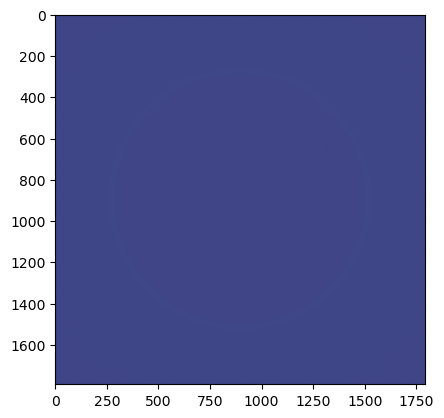

In [59]:
plt.imshow(reconstruction.mean(axis=0))
